In [1]:


from __future__ import print_function, division

import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim import lr_scheduler
import torch.backends.cudnn as cudnn
import numpy as np
import torchvision
from torchvision import datasets, models, transforms
import matplotlib.pyplot as plt
import time
import os
import copy
from glob import glob
import pandas as pd
from PIL import Image
import torchdata.datapipes as dp
import random
from torch.utils.data.backward_compatibility import worker_init_fn
from sklearn.metrics import classification_report
import wandb
import plotly.graph_objects as go

cudnn.benchmark = True
plt.ion()   # interactive mode


In [2]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_recall_fscore_support
from sklearn.metrics import roc_curve, roc_auc_score
from sklearn.metrics import precision_recall_curve
import plotly.graph_objects as go

# Split Data (Patient-wise)

In [4]:
annotation_df = pd.read_csv("WM_Annotations_with_augmented_counts.csv")

In [ ]:
def map_tag(filename):
    if filename.startswith("PD"):
        return "PDD"
    else:
        return "DLB"
annotation_df["LBD_tag"]=annotation_df["filename"].apply(lambda l : map_tag(l))
annotation_df = annotation_df.sort_values(by="filename").reset_index()
annotation_df["index"]=annotation_df.index

In [5]:
random_list = random.sample(range(0, 31), 20)
annotation_df["train_test_flag"]=np.where(annotation_df["index"].isin(random_list),"Train","Val")
annotation_df.groupby(["train_test_flag","LBD_tag"])["filename"].count()

train_test_flag  LBD_tag
Train            DLB        11
                 PDD         9
Val              DLB         4
                 PDD         7
Name: filename, dtype: int64

In [6]:
annotation_df

,level_0,Unnamed: 0.2,index,Unnamed: 0.1,Unnamed: 0,filename,filepath,WM_count,GM_count,bg_count,wm_gm_ratio,Aug_WM_count,Aug_GM_count,Aug_BG_count,wm_bg_ratio,gm_bg_ratio,LBD_tag,train_test_flag
0,0,0,0,21,21,11_063_CG_aSyn_x200.svs.geojson,/gladstone/finkbeiner/steve/work/data/npsad_da...,3678,2415,1056,0.761491,3678,4830,2112,3.482955,4.573864,DLB,Val
1,1,1,1,6,6,12_007_CG_aSyn_x200.svs.geojson,/gladstone/finkbeiner/steve/work/data/npsad_da...,2204,901,2891,1.223085,2204,1802,2891,0.762366,0.623314,DLB,Train
2,2,2,2,26,26,12_060_CG_aSyn_x200.svs.geojson,/gladstone/finkbeiner/steve/work/data/npsad_da...,5144,1708,2256,0.752927,5144,6832,4512,1.140071,1.514184,DLB,Train
3,3,3,3,5,5,13_131_CG_aSyn_x200.svs.geojson,/gladstone/finkbeiner/steve/work/data/npsad_da...,2439,5416,1008,0.900665,4878,5416,3024,2.419643,2.686508,DLB,Train
4,4,4,4,9,9,13_177_CG_aSyn_x200.svs.geojson,/gladstone/finkbeiner/steve/work/data/npsad_da...,3059,787,2422,0.971728,3059,3148,4844,0.631503,0.649876,DLB,Val
5,5,5,5,18,18,14_036_CG_aSyn_x200.svs.geojson,/gladstone/finkbeiner/steve/work/data/npsad_da...,3903,3965,1364,0.984363,3903,3965,2728,1.430718,1.453446,DLB,Train
6,6,6,6,7,7,14_053_CG_aSyn_x200.svs.geojson,/gladstone/finkbeiner/steve/work/data/npsad_da...,2189,3402,2293,0.643445,2189,3402,2293,0.954645,1.483646,DLB,Val
7,7,7,7,19,19,14_073_CG_aSyn_x200.svs.geojson,/gladstone/finkbeiner/steve/work/data/npsad_da...,2962,6405,1320,0.924902,5924,6405,3960,2.243939,2.426136,DLB,Train
8,8,8,8,27,27,14_075_CG_aSyn_x200.svs.geojson,/gladstone/finkbeiner/steve/work/data/npsad_da...,1920,4741,3084,0.809956,3840,4741,3084,1.245136,1.537289,DLB,Train
9,9,9,9,13,13,14_087_CG_aSyn_x200.svs.geojson,/gladstone/finkbeiner/steve/work/data/npsad_da...,782,55,879,0.888636,782,880,1758,0.444824,0.500569,DLB,Val


In [7]:
annotation_df.to_csv("WM_Annotations_with_augmented_counts.csv")

## Create a dataframe/csv data containing all image paths and labels

In [8]:
annotation_df = pd.read_csv("WM_Annotations_with_augmented_counts.csv")

In [ ]:
def map_label(class_name):
    if class_name=="White":
        return 0
    if class_name=="grey":
        return 1
    if class_name=="bg":
        return 2
    return -1

def create_df_from_folders(train_test_flag):
    patient_df = annotation_df[annotation_df["train_test_flag"]==train_test_flag]
    data_dir =  "/gladstone/finkbeiner/steve/work/data/npsad_data/monika/LBD/WM_images/"
    df = pd.DataFrame(columns=["WSI_filename","crop_filepath","class"])
    ind = 0
    for index in patient_df.index:
        folder_name = annotation_df.iloc[index]["filename"].replace(".geojson","")
        for label_name in ["White","grey","bg"]:
            files = glob(os.path.join(data_dir, folder_name, label_name, '*.png'))
            #print(len(files))
            temp_df =  pd.DataFrame({"crop_filepath":files})
            temp_df["WSI_filename"] = folder_name
            temp_df["class"] = label_name
            df = pd.concat([df, temp_df], ignore_index=True)
    df["label"]=df["class"].apply(lambda l:map_label(l))
    return df

train_df = create_df_from_folders("Train")
val_df = create_df_from_folders("Val")
#test_df = create_df_from_folders("Test")

print("Training Data Size :", len(train_df))
print("Validation Data Size :", len(val_df))
#print("Test Data Size : ", len(test_df))

In [ ]:
train_df.to_csv("train_full.csv")
val_df.to_csv("val_full.csv")

In [ ]:
train_df[["WSI_filename","crop_filepath","label"]].to_csv("train.csv")
val_df[["WSI_filename","crop_filepath","label"]].to_csv("val.csv")

In [ ]:
train_df["WSI_filename"].unique()

In [ ]:
val_df["WSI_filename"].unique()

In [ ]:
train1 = train_df[train_df["WSI_filename"].isin(['11_063_CG_aSyn_x200.svs', '12_007_CG_aSyn_x200.svs','PD002_Syn1_CG.svs', 'PD013_Syn1_CG.svs'])]
val1=val_df[val_df["WSI_filename"].isin(['13_177_CG_aSyn_x200.svs','PD034_Syn1_CG.svs'])]
train1[["WSI_filename","crop_filepath","label"]].to_csv("train1.csv")
val1[["WSI_filename","crop_filepath","label"]].to_csv("val1.csv")
print(len(train1))
print(len(val1))

## Build Torch Dataset

In [6]:
batch_size = 16

In [3]:
# Data augmentation and normalization for training
# Just normalization for validation
data_transforms = {
    'train': transforms.Compose([
        transforms.RandomResizedCrop(1024),
        #transforms.RandomHorizontalFlip(),
        #transforms.RandomVerticalFlip(),
        #transforms.FiveCrop(256),
        transforms.ToTensor(),
        transforms.Normalize([0.8478, 0.8328, 0.8679], [0.0932, 0.0973, 0.0825])
        #tensor([0.8478, 0.8328, 0.8679]) tensor([0.0932, 0.0973, 0.0825])
    ]),
    'val': transforms.Compose([
        transforms.Resize(1024),
        #transforms.CenterCrop(256),
        transforms.ToTensor(),
        transforms.Normalize([0.8478, 0.8328, 0.8679], [0.0932, 0.0973, 0.0825])
    ]),
    'test': transforms.Compose([
        transforms.Resize(1024),
        #transforms.CenterCrop(256),
        transforms.ToTensor(),
        transforms.Normalize([0.8478, 0.8328, 0.8679], [0.0932, 0.0973, 0.0825])
    ]),
}


In [4]:
def open_image(inputs):
    _ , wsi_name, img_path, label = inputs
    img = Image.open(img_path)
    return wsi_name, img, int(label)

def apply_train_transforms(inputs):
    _, x, y = inputs
    return data_transforms["train"](x), y

def apply_val_transforms(inputs):
    wsi_name, x, y = inputs
    return wsi_name, data_transforms["val"](x), y

def build_data_pipe(csv_file, transform , batch_size=32):
    new_dp = dp.iter.FileOpener([csv_file])
    new_dp = new_dp.parse_csv(skip_lines=1)
    # returns tuples like ('0','filename', 'filepath', 'label')
    if transform == "train":
        new_dp = new_dp.shuffle()
    
        new_dp = new_dp.sharding_filter()
    # important to use sharding_filter after (not before) shuffling -For the data source that needs to be sharded, it is crucial to add Shuffler before ShardingFilter to ensure data are globally shuffled before being split into shards. Otherwise, each worker process would always process the same shard of data for all epochs. And, it means each batch would only consist of data from the same shard, which leads to low accuracy during training. However, it doesn’t apply to the data source that has already been sharded for each multi-/distributed process, since ShardingFilter is no longer required to be presented in the pipeline.

    new_dp = new_dp.map(open_image)

    if transform == "train":
        new_dp = new_dp.map(apply_train_transforms)
        new_dp = new_dp.batch(batch_size=batch_size, drop_last=True)

    elif transform == "val":
        new_dp = new_dp.map(apply_val_transforms)
        new_dp = new_dp.batch(batch_size=batch_size, drop_last=False)

    else:
        raise ValueError("Invalid transform argument.")

    new_dp = new_dp.map(torch.utils.data.default_collate)
    return new_dp

In [22]:
train_dp = build_data_pipe("/gladstone/finkbeiner/steve//work/data/npsad_data/monika/LBD/Intermediate_data/train.csv", "train", batch_size)
val_dp = build_data_pipe("/gladstone/finkbeiner/steve//work/data/npsad_data/monika/LBD/Intermediate_data/val.csv", "val", batch_size)

In [18]:
train_dp = build_data_pipe("train1.csv", "train", batch_size)
val_dp = build_data_pipe("val1.csv", "val", batch_size)

In [23]:
def dataset_size(csv_file):
    df = pd.read_csv(csv_file)
    return len(df)

train_datasize = dataset_size("train.csv")
val_datasize = dataset_size("val.csv")

In [24]:
dataset_sizes = {'train':train_datasize, 'val':val_datasize}

In [25]:
dataset_sizes

{'train': 155698, 'val': 83219}

In [26]:
train_loader = torch.utils.data.DataLoader(
    dataset=train_dp, shuffle=True, num_workers=4)

val_loader = torch.utils.data.DataLoader(
    dataset=val_dp, shuffle=False, num_workers=4)

dataloaders = {"train":train_loader, "val": val_loader}

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")



#imagenames = sorted(glob(os.path.join(wsi_home_dir, './*/*.svs')))
imagenames = sorted(glob(os.path.join(data_dir, './*/*.png')))
#pdd_imagenames = sorted(glob(os.path.join(pdd_wsi_dir, '././*.svs')))



data_dir =  "/gladstone/finkbeiner/steve/work/data/npsad_data/monika/LBD/WM_images/"
image_datasets = {x: datasets.ImageFolder(os.path.join(data_dir, x),
                                          data_transforms[x])
                  for x in ['train', 'val', 'test']}

dataloaders = {x: torch.utils.data.DataLoader(image_datasets[x], batch_size=4,
                                             shuffle=True, num_workers=4)
              for x in ['train', 'val', 'test']}

dataset_sizes = {x: len(image_datasets[x]) for x in ['train', 'val','test']}
class_names = image_datasets['train'].classes

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")



data_dir =  "/gladstone/finkbeiner/steve/work/data/npsad_data/monika/LBD/WM_images/"
image_datasets = {x: datasets.ImageFolder(os.path.join(data_dir, x),
                                          transform = data_transforms['train'])
                  for x in ['11_063_CG_aSyn_x200.svs']}

image_datasets1 = {x: datasets.ImageFolder(os.path.join(data_dir, x),
                                          transform = data_transforms['train'])
                  for x in ['11_063_CG_aSyn_x200.svs']}



dataloaders = {x: torch.utils.data.DataLoader(image_datasets[x], batch_size=4,
                                             shuffle=True, num_workers=4)
              for x in ['11_063_CG_aSyn_x200.svs']}


dataloaders1 = {x: torch.utils.data.DataLoader(image_datasets1[x], batch_size=4,
                                             shuffle=True, num_workers=4)
              for x in ['11_063_CG_aSyn_x200.svs']}

dataset_sizes = {x: len(image_datasets) for x in ['11_063_CG_aSyn_x200.svs']}
#class_names = image_datasets['train'].classes


data_dir =  "/gladstone/finkbeiner/steve/work/data/npsad_data/monika/LBD/WM_images/"
image_datasets = {x: datasets.ImageFolder(os.path.join(data_dir, x),
                                          transform = data_transforms['train'])
                  for x in ['11_063_CG_aSyn_x200.svs']}

image_datasets1 = {x: datasets.ImageFolder(os.path.join(data_dir, x),
                                          transform = data_transforms['train'])
                  for x in ['11_063_CG_aSyn_x200.svs']}

increased_dataset = torch.utils.data.ConcatDataset([image_datasets,image_datasets1])

dataloaders = torch.utils.data.DataLoader(increased_dataset, batch_size=4,
                                             shuffle=True, num_workers=4)


import os, os.path
DIR = "/gladstone/finkbeiner/steve/work/data/npsad_data/monika/LBD/WM_images3/train"
print(os.listdir(DIR))
for f in os.listdir(DIR):
    d =  os.listdir(os.path.join(DIR,f))
    print(f, len(d))

data_dir =  "/gladstone/finkbeiner/steve/work/data/npsad_data/monika/LBD/WM_images/"
image_datasets = {x: datasets.ImageFolder(os.path.join(data_dir, x),
                                          transform = data_transforms['train'])
                  for x in ['11_063_CG_aSyn_x200.svs']}

dataloaders = {x: torch.utils.data.DataLoader(image_datasets[x], batch_size=4,
                                             shuffle=True, num_workers=4)
              for x in ['11_063_CG_aSyn_x200.svs']}

torch.Size([32, 3, 1024, 1024])
tensor([[0, 0, 0, 0, 1, 0, 0, 1, 2, 1, 1, 0, 0, 1, 2, 1, 0, 1, 0, 1, 0, 1, 0, 2,
         0, 1, 2, 1, 0, 1, 1, 0]])
torch.Size([3, 4106, 8210])
torch.Size([3, 4106, 8210])
(4106, 8210, 3)


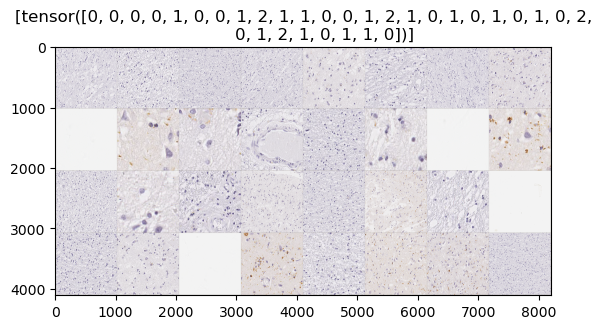

In [12]:
def imshow(inp, title=None):
    """Imshow for Tensor."""
    inp = inp.squeeze()
    print(inp.shape)
    #inp = inp.numpy().transpose((0, 3, 2, 1))
    inp = inp.numpy().transpose((1, 2, 0))
    
    print(inp.shape)
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    inp = std * inp + mean
    inp = np.clip(inp, 0, 1)
    plt.imshow(inp)
    if title is not None:
        plt.title(title)
    plt.pause(0.001)  # pause a bit so that plots are updated


# Get a batch of training data
inputs, classes = next(iter(dataloaders['train']))
inputs = inputs.squeeze()
print(inputs.shape)
print(classes)

# Make a grid from batch
out = torchvision.utils.make_grid(inputs)
print(out.shape)
imshow(out, title=[x for x in classes])

## Train Model

In [27]:
train_config = dict(
    epochs = 25,
    batch_size = batch_size,
    num_classes = 3,
    device_id = 0,
    eval_freq = 5,
)



model_config = dict(lr=0.001, momentum=0.9)

optim_config = dict(step_size=7, gamma=0.1)


wandb_config = dict(
    project='LBD',
    entity='monika-ahirwar',
    config=dict(
        train_config=train_config,
        model_config=model_config,
        optim_config=optim_config,
    ),
    save_code=False,
    group='runs',
    job_type='train',
)
run = wandb.init(**wandb_config)
assert run is wandb.run # run was successfully initialized, is not None
run_id, run_dir = run.id, run.dir
exp_name = run.name
artifact_name = f'{run_id}-logs'
eval_path = "/gladstone/finkbeiner/steve/work/data/npsad_data/monika/LBD/WM_Evaluation_Metrics/"+run_id

if not os.path.exists(eval_path):
    os.makedirs(eval_path)

WANDB_NOTEBOOK_NAME = "WM_Classification_4.ipynb"


Evaluation Metric for WSI :13_177_CG_aSyn_x200.svs,0.66935
Evaluation Metric for WSI :14_036_CG_aSyn_x200.svs,0.6057
Evaluation Metric for WSI :14_087_CG_aSyn_x200.svs,0.71257
Evaluation Metric for WSI :14_133_CG_aSyn_x200.svs,0.6328
Evaluation Metric for WSI :14_148_CG_aSyn_x200.svs,0.55419
Evaluation Metric for WSI :PD001_Syn1_CG.svs,0.67891
Evaluation Metric for WSI :PD034_Syn1_CG.svs,0.48236
Evaluation Metric for WSI :PD061_Syn1_CG.svs,0.70201
Evaluation Metric for WSI :PD088_Syn1_CG.svs,0.55802
Evaluation Metric for WSI :PD110_Syn1_CG.svs,0.3724
Evaluation Metric for WSI :PD131_Syn1_CG.svs,0.53674


In [28]:
test_config = dict(
    batch_size = 32
)

In [31]:
def plot_roc_auc_curve(run, actual_labels, y_scores, classes, wsi_name):
    y_onehot = pd.get_dummies(actual_labels, columns=classes)
    y_scores = pd.DataFrame(y_scores)
    for i, c in enumerate(classes):
        y_scores[c]=y_scores["scores"].apply(lambda l: l[i])
    y_scores.drop(["scores"], axis=1,inplace=True)
    
    
    fig = go.Figure()
    fig.add_shape(
        type='line', line=dict(dash='dash'),
        x0=0, x1=1, y0=0, y1=1
    )

    for i in range(len(classes)):
        y_true = y_onehot.iloc[:, i]
        y_score = y_scores.iloc[:, i]

        fpr, tpr, _ = roc_curve(y_true, y_score)
        auc_score = roc_auc_score(y_true, y_score)

        name = f"{y_onehot.columns[i]} (AUC={auc_score:.2f})"
        fig.add_trace(go.Scatter(x=fpr, y=tpr, name=name, mode='lines'))

    fig.update_layout(
        xaxis_title='False Positive Rate',
        yaxis_title='True Positive Rate',
        yaxis=dict(scaleanchor="x", scaleratio=1),
        xaxis=dict(constrain='domain'),
        width=700, height=500
    )
    fig.write_html(os.path.join(eval_path, "ROC_Curve" + wsi_name +".html"), auto_play = False)
    table = wandb.Table(columns = [wsi_name], data=[wandb.Html(os.path.join(eval_path, "ROC_Curve" + wsi_name +".html"))])
    #table.add_data(wandb.Html(os.path.join(eval_path, "ROC_Curve" + wsi_name +".html")))
    run.log({"ROC Curve": table})



def plot_pr_curve(run, actual_labels, y_scores, classes, wsi_name):
    table = wandb.Table(columns = [wsi_name])
    y_onehot = pd.get_dummies(actual_labels, columns=classes)
    y_scores = pd.DataFrame(y_scores)
    for i, c in enumerate(classes):
        y_scores[c]=y_scores["scores"].apply(lambda l: l[i])
    y_scores.drop(["scores"], axis=1,inplace=True)
    
    fig = go.Figure()
    for i in range(len(classes)):
        y_true = y_onehot.iloc[:, i]
        y_score = y_scores.iloc[:, i]
        precision, recall, thresholds = precision_recall_curve(y_true, y_score)
        fig.add_trace(go.Scatter(x=recall, y=precision, name=classes[i], mode='lines'))

    fig.update_layout(
        xaxis_title='Recall',
        yaxis_title='Precision',
        yaxis=dict(scaleanchor="x", scaleratio=1),
        xaxis=dict(constrain='domain'),
        width=700, height=500
    )

    fig.write_html(os.path.join(eval_path, "PR_Curve" + wsi_name +".html"), auto_play = False)
    table.add_data(wandb.Html(os.path.join(eval_path, "PR_Curve" + wsi_name +".html")))
    run.log({"PR Curve": table})



def plot_training_curve(log_metrics):
    # Create traces
    log_metrics = pd.DataFrame(log_metrics)
    for c in ["loss", "metrics"]:
        fig = go.Figure()
        if c=="loss":
            fig.add_trace(go.Scatter(x=log_metrics[log_metrics["phase"]=="train"]["epoch"], y=log_metrics[log_metrics["phase"]=="train"][c],
                                mode='lines+markers',
                                name='Training loss'))
            #fig.add_trace(go.Scatter(x=log_metrics[log_metrics["phase"]=="val"]["epoch"], y=log_metrics[log_metrics["phase"]=="val"][c],
            #                    mode='lines+markers',
            #                    name='Validation loss'))

            fig.update_layout(title='Training/Validation loss vs Epoch',
                            xaxis_title='Epoch No',
                            yaxis_title='Loss')

            fig.write_html(eval_path + "Training_loss_curve.html")
            table = wandb.Html(eval_path + "Training_loss_curve.html")
            wandb.log({"Training Loss":table})
        else:
            fig.add_trace(go.Scatter(x=log_metrics[log_metrics["phase"]=="train"]["epoch"], y=log_metrics[log_metrics["phase"]=="train"][c],
                                mode='lines+markers',
                                name='Training Accuracy'))
            #fig.add_trace(go.Scatter(x=log_metrics[log_metrics["phase"]=="val"]["epoch"], y=log_metrics[log_metrics["phase"]=="val"][c],
            #                    mode='lines+markers',
            #                    name='Validation Accuracy'))           

            fig.update_layout(title='Training/Validation Acccuracy vs Epoch',
                            xaxis_title='Epoch No',
                            yaxis_title='Accuracy')

            fig.write_html(eval_path + "Training_Accuracy_curve.html")
            table = wandb.Html(eval_path + "Training_Accuracy_curve.html")
            wandb.log({"Training Accuracy":table})

In [29]:
def test_model(model, run):
    was_training = model.training
    model.eval()
    actual_labels = []
    pred_labels = []
    wsi_names = []
    scores=[]
    with torch.no_grad():
        for i, (wsi, inputs, labels) in enumerate(dataloaders['val']):
            inputs=inputs.squeeze()
            labels = labels.squeeze()
            inputs = inputs.to(device)
            labels = labels.to(device)
            actual_labels.extend(labels.tolist())
            outputs = model(inputs)
            scores.extend(outputs.cpu().tolist())
            _, preds = torch.max(outputs, 1)
            pred_labels.extend(preds.tolist())
            wsi=[x[0] for x in wsi]
            wsi_names.extend(wsi)
            output_df = pd.DataFrame({"wsi_name":wsi_names,"actual_labels":actual_labels,"pred_labels":pred_labels,"scores":scores})
            if i%500==0:
                print(i, "Done")
        classes = [0,1,2]
        eval_metrics = pd.DataFrame(columns=["WSI","accu_score","precision-white","recall-white","f1-score-white","support-white", "precision-grey","recall-grey","f1-score-grey","support-grey", "precision-bg","recall-bg","f1-score-bg","support-bg"])
        ind =0 
        for wsi in output_df['wsi_name'].unique():
            tmp = output_df[output_df["wsi_name"]==wsi]  
            acc_score = accuracy_score(tmp["actual_labels"], tmp["pred_labels"])
            prec_rec = precision_recall_fscore_support(tmp["actual_labels"], tmp["pred_labels"], labels=[0,1,2])
            eval_metrics.loc[ind] = (wsi, acc_score, prec_rec[0][0],prec_rec[1][0],prec_rec[2][0],prec_rec[3][0], prec_rec[0][1],prec_rec[1][1],prec_rec[2][1],prec_rec[3][1], prec_rec[0][2],prec_rec[1][2],prec_rec[2][2],prec_rec[3][2] )
            plot_roc_auc_curve(run, tmp["actual_labels"], tmp["scores"], classes, wsi)
            plot_pr_curve(run, tmp["actual_labels"], tmp["scores"], classes, wsi)
            ind=ind+1
            wandb.summary["Evaluation Metric for WSI :" + wsi]=acc_score
        
        tbl = wandb.Table(data=eval_metrics)
        run.log({"Test Evaluation Metric": tbl})
        eval_metrics.to_csv(eval_path + "eval_metric.csv")
        print(eval_metrics)

In [17]:
def train_model(run, model, criterion, optimizer, scheduler, num_epochs=25):
    since = time.time()

    best_model_wts = copy.deepcopy(model.state_dict())
    best_acc = 0.0
    log_metrics = list()

    for epoch in range(num_epochs):
        print(f'Epoch {epoch}/{num_epochs - 1}')
        print('-' * 10)

        # Each epoch has a training and validation phase
        for phase in ['train']:
            if phase == 'train':
                model.train()  # Set model to training mode
            else:
                model.eval()   # Set model to evaluate mode

            running_loss = 0.0
            running_corrects = 0

            # Iterate over data.
            for i, (inputs, labels) in enumerate(dataloaders[phase]):
                inputs=inputs.squeeze()
                labels = labels.squeeze()
                inputs = inputs.to(device)
                labels = labels.to(device)

                # zero the parameter gradients
                optimizer.zero_grad()

                # forward
                # track history if only in train
                with torch.set_grad_enabled(phase == 'train'):
                    outputs = model(inputs)
                    _, preds = torch.max(outputs, 1)
                    loss = criterion(outputs, labels)

                    # backward + optimize only if in training phase
                    if phase == 'train':
                        loss.backward()
                        optimizer.step()

                # statistics
                running_loss += loss.item() * inputs.size(0)
                running_corrects += torch.sum(preds == labels.data)

                print(f'{phase} Loss: {loss.item():.4f} Batch No: {i}')
            if phase == 'train':
                scheduler.step()

            epoch_loss = running_loss / dataset_sizes[phase]
            epoch_acc = running_corrects.double() / dataset_sizes[phase]

            print(f'{phase} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}')
            log_metrics.append(dict(epoch=epoch,phase=phase, loss=epoch_loss, metrics=epoch_acc))
            # deep copy the model
        
        #if (epoch+1)%train_config["eval_freq"]==0:
        #    test_model(model)
            
            #if phase == 'val' and epoch_acc > best_acc:
            ##if phase == 'val' and epoch+1==train_config["eval_freq"]:
                #test_model(model)
            #    best_acc = epoch_acc
            #    best_model_wts = copy.deepcopy(model.state_dict())
            
    time_elapsed = time.time() - since
    print(f'Training complete in {time_elapsed // 3600:.0f}h {time_elapsed % 60:.0f}m')
    print(f'Best val Acc: {best_acc:4f}')
    #plot_training_curve(log_metrics)
    # load best model weights
    model.load_state_dict(best_model_wts)
    run.log({"log":log_metrics})
    torch.save({"model":model, "state": model.state_dict()}, '/gladstone/finkbeiner/steve/work/data/npsad_data/monika/LBD/WM_models/'+artifact_name+'.pth')
    artifact = wandb.Artifact(artifact_name, type='files')
    with artifact.new_file(f'ckpt/{epoch}.pt', 'wb') as f:
        torch.save(model.state_dict(), f)
    run.log_artifact(artifact)
    run.finish()
    return model, log_metrics

In [7]:
def visualize_model(model, num_images=20):
    was_training = model.training
    model.eval()
    images_so_far = 0
    fig = plt.figure()

    with torch.no_grad():
        for i, (inputs, labels) in enumerate(dataloaders['test']):
            inputs = inputs.to(device)
            labels = labels.to(device)

            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            print(labels)
            for j in range(inputs.size()[0]):
                images_so_far += 1
                ax = plt.subplot(num_images//2, 2, images_so_far)
                ax.axis('off')
                ax.set_title(f'predicted: {class_names[preds[j]]}')
                imshow(inputs.cpu().data[j])

                if images_so_far == num_images:
                    model.train(mode=was_training)
                    return
        model.train(mode=was_training)


In [30]:
model_ft = models.resnet18(pretrained=True)
num_ftrs = model_ft.fc.in_features
# Here the size of each output sample is set to 2.
# Alternatively, it can be generalized to nn.Linear(num_ftrs, len(class_names)).
model_ft.fc = nn.Linear(num_ftrs, train_config["num_classes"])

model_ft = model_ft.to(device)

criterion = nn.CrossEntropyLoss()

# Observe that all parameters are being optimized
optimizer_ft = optim.SGD(model_ft.parameters(), lr=0.001, momentum=0.9)
#optimizer_ft = optim.Adam(model_ft.parameters(), lr=0.0001)

# Decay LR by a factor of 0.1 every 7 epochs
exp_lr_scheduler = lr_scheduler.StepLR(optimizer_ft, step_size=7, gamma=0.1)

/home/mahirwar/miniconda3/envs/kfold_amy_plaque1/lib/python3.9/site-packages/torchvision/models/_utils.py:208: UserWarning:

The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.

/home/mahirwar/miniconda3/envs/kfold_amy_plaque1/lib/python3.9/site-packages/torchvision/models/_utils.py:223: UserWarning:

Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.



In [32]:
#start = torch.cuda.Event(enable_timing=True)
model_ft, log_metrics = train_model(run, model_ft, criterion, optimizer_ft, exp_lr_scheduler,
                       num_epochs=train_config["epochs"])
plot_training_curve(log_metrics)
#end = torch.cuda.Event(enable_timing=True)
#torch.cuda.synchronize()

#print(start.elapsed_time(end))

Epoch 0/24
----------


train Loss: 1.1298 Batch No: 0
train Loss: 1.1302 Batch No: 1
train Loss: 0.9725 Batch No: 2
train Loss: 0.9629 Batch No: 3
train Loss: 0.8362 Batch No: 4
train Loss: 0.7739 Batch No: 5
train Loss: 0.4928 Batch No: 6
train Loss: 0.4913 Batch No: 7
train Loss: 0.4732 Batch No: 8
train Loss: 0.3952 Batch No: 9
train Loss: 0.3715 Batch No: 10
train Loss: 0.2122 Batch No: 11
train Loss: 0.3094 Batch No: 12
train Loss: 0.2760 Batch No: 13
train Loss: 0.4085 Batch No: 14
train Loss: 0.2380 Batch No: 15
train Loss: 0.1543 Batch No: 16
train Loss: 0.2041 Batch No: 17
train Loss: 0.1885 Batch No: 18
train Loss: 0.1586 Batch No: 19
train Loss: 0.1493 Batch No: 20
train Loss: 0.0931 Batch No: 21
train Loss: 0.0437 Batch No: 22
train Loss: 0.0671 Batch No: 23
train Loss: 0.0581 Batch No: 24
train Loss: 0.0841 Batch No: 25
train Loss: 0.0956 Batch No: 26
train Loss: 0.0267 Batch No: 27
train Loss: 0.0788 Batch No: 28
train Loss: 0.2042 Batch No: 29
train Loss: 0.0411 Batch No: 30
train Loss: 0.0340

KeyboardInterrupt: 

wandb: ERROR Dropped streaming file chunk (see wandb/debug-internal.log)
wandb: ERROR Dropped streaming file chunk (see wandb/debug-internal.log)
wandb: ERROR Dropped streaming file chunk (see wandb/debug-internal.log)
wandb: ERROR Dropped streaming file chunk (see wandb/debug-internal.log)
wandb: ERROR Dropped streaming file chunk (see wandb/debug-internal.log)
wandb: ERROR Dropped streaming file chunk (see wandb/debug-internal.log)
wandb: ERROR Dropped streaming file chunk (see wandb/debug-internal.log)
wandb: ERROR Dropped streaming file chunk (see wandb/debug-internal.log)
wandb: ERROR Dropped streaming file chunk (see wandb/debug-internal.log)
wandb: ERROR Dropped streaming file chunk (see wandb/debug-internal.log)
wandb: ERROR Dropped streaming file chunk (see wandb/debug-internal.log)
wandb: ERROR Dropped streaming file chunk (see wandb/debug-internal.log)
wandb: ERROR Dropped streaming file chunk (see wandb/debug-internal.log)
wandb: ERROR Dropped streaming file chunk (see wand

In [18]:
import gc
def report_gpu():
   print(torch.cuda.list_gpu_processes())
   gc.collect()
   torch.cuda.empty_cache()

In [20]:
import gc
gc.collect()
torch.cuda.empty_cache()

## Test Model

In [19]:
#torch.save({"model":model_ft, "state": model_ft.state_dict()}, '/gladstone/finkbeiner/steve/work/data/npsad_data/monika/LBD/WM_models/model_4_dlb_4_pdd.pth')

def load_saved_model(path):
    checkpoint = torch.load(path)
    model_ft = checkpoint["model"]
    model_ft.load_state_dict(checkpoint['state'])
    return model_ft

In [18]:
path = '/gladstone/finkbeiner/steve/work/data/npsad_data/monika/LBD/WM_models/2nqho457-logs2.pth'

In [16]:
#path = '/gladstone/finkbeiner/steve/work/data/npsad_data/monika/LBD/WM_models/10dibtjj-logs.pth'

In [ ]:
#torch.save({"model":model_ft, "state": model_ft.state_dict()}, '/gladstone/finkbeiner/steve/work/data/npsad_data/monika/LBD/WM_models/2nqho457-logs2.pth')

In [20]:
model_ft = load_saved_model(path)

In [21]:
test_model(model_ft,run)

0 Done
500 Done
1000 Done
1500 Done
2000 Done
2500 Done
3000 Done
3500 Done
4000 Done
4500 Done
5000 Done
5500 Done
6000 Done
6500 Done
7000 Done
7500 Done
8000 Done
8500 Done
9000 Done
9500 Done
10000 Done
10500 Done
11000 Done
11500 Done
12000 Done
12500 Done
13000 Done
13500 Done
14000 Done
14500 Done
15000 Done
15500 Done
16000 Done
16500 Done
17000 Done
17500 Done
18000 Done
18500 Done
19000 Done
19500 Done
20000 Done
20500 Done


/home/mahirwar/miniconda3/envs/kfold_amy_plaque1/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1334: UndefinedMetricWarning:

Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.

/home/mahirwar/miniconda3/envs/kfold_amy_plaque1/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1334: UndefinedMetricWarning:

Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.

/home/mahirwar/miniconda3/envs/kfold_amy_plaque1/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1334: UndefinedMetricWarning:

Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.

/home/mahirwar/miniconda3/envs/kfold_amy_plaque1/lib/python3.9/site-packages/sklearn/metrics/_classification.py:

                        WSI  accu_score  precision-white  recall-white  \
0   13_177_CG_aSyn_x200.svs    0.669351         0.904205      0.934946   
1   14_036_CG_aSyn_x200.svs    0.605700         0.982428      0.945427   
2   14_087_CG_aSyn_x200.svs    0.712573         1.000000      0.868286   
3   14_133_CG_aSyn_x200.svs    0.632800         0.998755      0.718381   
4   14_148_CG_aSyn_x200.svs    0.554190         1.000000      0.577008   
5         PD001_Syn1_CG.svs    0.678906         0.787810      0.745726   
6         PD034_Syn1_CG.svs    0.482358         1.000000      0.664874   
7         PD061_Syn1_CG.svs    0.702007         0.998739      0.773438   
8         PD088_Syn1_CG.svs    0.558016         0.988245      0.902649   
9         PD110_Syn1_CG.svs    0.372396         1.000000      0.550514   
10        PD131_Syn1_CG.svs    0.536739         1.000000      0.208333   

    f1-score-white  support-white  precision-grey  recall-grey  f1-score-grey  \
0         0.919319          12

# Segmentation Task

In [ ]:
import pyvips as Vips
import numpy as np
from Reinhard import Reinhard
import cv2
from PIL import Image

In [ ]:
def getVipsInfo(vips_img):
    # # Get bounds-x and bounds-y offeset
    vfields = [f.split('.') for f in vips_img.get_fields()]
    vfields = [f for f in vfields if f[0] == 'openslide']
    vfields = dict([('.'.join(k[1:]), vips_img.get('.'.join(k))) for k in vfields])
    return vfields

def normalization(REF_IMG_PATH):
    print("Init Normalization")
    ref_image = Vips.Image.new_from_file(REF_IMG_PATH)
    normalizer = Reinhard()
    normalizer.fit(ref_image)
    return normalizer

In [ ]:
## Load model
#path = 'model_dlb1.pth'
def load_saved_model(path):
    checkpoint = torch.load(path)
    model_ft = checkpoint["model"]
    model_ft.load_state_dict(checkpoint['state'])
    return model_ft

In [ ]:
REF_IMG_PATH =  '/gladstone/finkbeiner/steve/work/data/npsad_data/monika/LBD_Dataset/LBD/./DLB_cases/11_063_CG_aSyn_x200.svs'
#img  =  '/gladstone/finkbeiner/steve/work/data/npsad_data/monika/LBD_Dataset/LBD/./DLB_cases/11_063_CG_aSyn_x200.svs'
#img = '/gladstone/finkbeiner/steve/work/data/npsad_data/monika/LBD_Dataset/LBD/./DLB_cases/11_063_CG_aSyn_x200.svs' 
img = '/gladstone/finkbeiner/steve/work/data/npsad_data/monika/LBD_Dataset/LBD/PDD_cases/PDD_cases/././PD017_Syn1_CG.svs'
stride = 128
tilesize = 1024
path  ='model_full2.pth'


def predict_crop_class(model_ft, crop):
    crop_array = np.ndarray(buffer=crop.write_to_memory(), dtype=np.uint8, shape=(tilesize, tilesize, crop.bands))
    crop_array = crop_array[:,:,:3]
    #crop_array = torch.from_numpy(crop_array.transpose((2,0,1)))
    #crop_array = crop_array.transpose(2,0,1)
    img = Image.fromarray(crop_array.astype('uint8'), 'RGB')
    #img = Image.fromarray(np.uint8(crop_array.transpose((2,0,1)))).convert('RGB')
    transformed_img = data_transforms["test"](img)
    transformed_img = torch.unsqueeze(transformed_img, dim=0)
    outputs = model_ft(transformed_img.to(device).float())
    _, preds = torch.max(outputs, 1)
    return preds.tolist()


def construct_wsi_mask(stride, tilesize,REF_IMG_PATH,img):
    normalizer = normalization(REF_IMG_PATH)
    vips_img = Vips.Image.new_from_file(img, level=0)
    vips_img = normalizer.transform(vips_img)
    vinfo = getVipsInfo(vips_img)
    orig_w, orig_h = int(vinfo['level[0].width']), int(vinfo['level[0].height'])
    vips_array = np.ndarray(buffer=vips_img.write_to_memory(), dtype=np.uint8, shape=(vips_img.height, vips_img.width, vips_img.bands))
    vips_array = vips_array[:,:,:3]
    vips_array_copy =vips_array.copy()
    masked_image = np.zeros((orig_h,orig_w,3))
    count_predictions = {"white":0,"grey":0,"bg":0}
    #model_ft =  load_saved_model(path)
    for y_val in range(0, orig_h-stride, stride):
        for x_val in range(0, orig_w-stride, stride): 
                if y_val + tilesize < orig_h and x_val + tilesize < orig_w:
                    crop = vips_img.crop(x_val, y_val, tilesize, tilesize)
                    crop_pred =  predict_crop_class(model_ft, crop)
                    print(crop_pred)
                    if crop_pred==[0]:
                        count_predictions["white"] = count_predictions["white"]+1
                        masked_image[x_val:x_val+tilesize, y_val:y_val+tilesize] = [0,0,255]
                        vips_array_copy = cv2.rectangle(vips_array_copy,(x_val, y_val),(x_val + tilesize,y_val + tilesize),(0,0,255),30)
                    if crop_pred==[1]:
                        count_predictions["bg"] = count_predictions["bg"]+1
                        masked_image[x_val:x_val+tilesize, y_val:y_val+tilesize] = [255,0,0]
                        vips_array_copy = cv2.rectangle(vips_array_copy,(x_val, y_val),(x_val + tilesize,y_val + tilesize),(255,0,0),30)
                    if crop_pred==[2]:
                        count_predictions["grey"] = count_predictions["grey"]+1
                        masked_image[x_val:x_val+tilesize, y_val:y_val+tilesize] = [0,255,0]
                        vips_array_copy = cv2.rectangle(vips_array_copy,(x_val, y_val),(x_val + tilesize,y_val + tilesize),(0,255,0),30)
    return masked_image, vips_array_copy, count_predictions

def print_thumnail(img1):
    th1 = Image.fromarray(img1.astype(np.uint8))
    th1.thumbnail((1000,1000))
    return th1
        

In [ ]:
masked_image, vips_array_copy, count_predictions = construct_wsi_mask(stride, tilesize,REF_IMG_PATH,img)

In [ ]:
count_predictions

In [ ]:
print_thumnail(vips_array_copy)